In [12]:
%load_ext autoreload
%autoreload 2

import sys
import os
import typing as tp
import math
from importlib import reload

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple, List
from mars import spin_model, spectra_manager, mesher, constants
import mars

from sample_creators_local import (
                             create_5_electrons_sample, create_2_electrons_2_nuclei_sample,
                             create_1_high_spin_electron_1_nuclei_sample, create_2_middle_spin_sample
                            )

from saving_benchmarks import save_benchmark_results, load_benchmark_results

from bencmarking import benchmark_several_configurations, compare_benchmarks, plot_benchmark_comparison, time_spectrum_calculation_full_pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import matplotlib.pyplot as plt

In [14]:
dtype = torch.float64
device = torch.device("cpu")

### Sample 1.

In [15]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=20, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

In [16]:
sample_Mn = create_1_high_spin_electron_1_nuclei_sample(mesh=mesh, device="cpu", dtype=dtype)


freq = 35.0 * 1e9,
field_range = (1.15, 1.325)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_Mn,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_Mn, fields=fields)

tensor(0.0001, dtype=torch.float64)


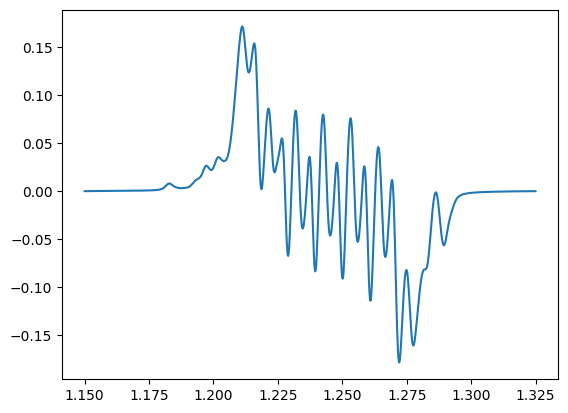

In [6]:
plt.plot(fields, out)

In [308]:
#mars.save("easyspin/out_1.mat", sample=sample_Mn, spectra_creator=creator, field=fields, format_type="easyspin")
#data_frame = pd.DataFrame({"field": fields, "spec": out})

#data_frame.to_csv(f"easyspin/spectrum_1.csv", header=False, index=False)

Check time

In [8]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_1_high_spin_electron_1_nuclei_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(1627.3428599815816,
 6.815122291521416,
 [1616.7565999785438,
  1628.1839999137446,
  1629.7826999798417,
  1624.407000024803,
  1637.5840000109747])

### Sample 2.

In [9]:
mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=20, interpolation_grid_frequency=100, interpolator="rbf", dtype=dtype, interpolate=False)

sample_two_spins = create_2_middle_spin_sample(mesh=mesh, device="cpu", dtype=dtype)

freq = 35.0 * 1e9,
field_range = (1.22, 1.265)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_two_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)
    
out = creator(sample=sample_two_spins, fields=fields)

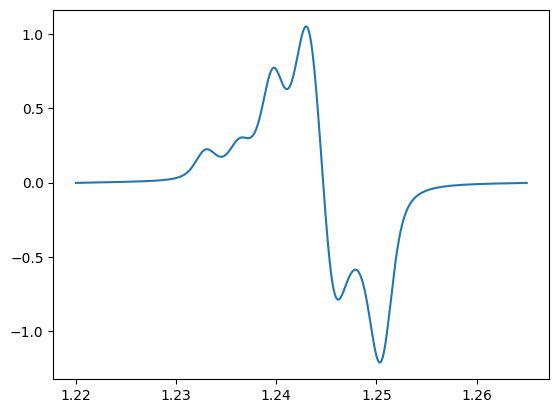

In [10]:
plt.plot(fields, out)

In [298]:
mars.save("easyspin/out_2.mat", sample=sample_two_spins, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_2.csv", header=False, index=False)

In [11]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_2_middle_spin_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(160.2055599913001,
 7.548868911192521,
 [155.1289000781253,
  148.19039998110384,
  166.56549996696413,
  162.67709992825985,
  168.46590000204742])

### Sample 3.

In [17]:
sample_5_electrons = create_5_electrons_sample(mesh=mesh, device="cpu", dtype=dtype)


freq = 9.8 * 1e9,
field_range = (0.3, 0.4)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(integration_computation_method="mean")

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_5_electrons,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5_electrons, fields=fields)

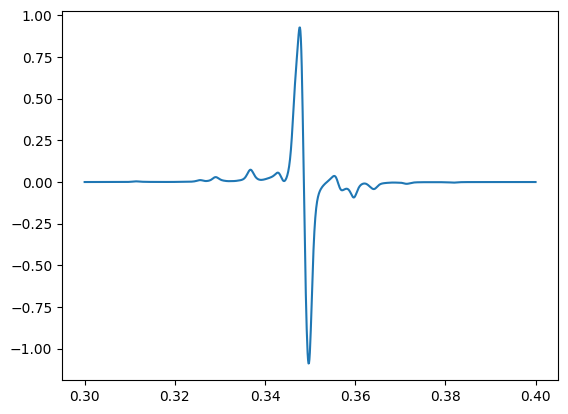

In [310]:
plt.plot(fields, out)

In [311]:
mars.save("easyspin/out_3.mat", sample=sample_5_electrons, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_3.csv", header=False, index=False)

In [18]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)


time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_5_electrons_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(999.629639997147,
 165.9954095066093,
 [915.1247999398038,
  1328.7471999647096,
  890.9423999721184,
  956.7882000701502,
  906.5456000389531])

### Sample 4.

In [20]:
sample_2_el_2_nuc = create_2_electrons_2_nuclei_sample(mesh=mesh, device="cpu", dtype=dtype)

In [21]:
freq = 9.8 * 1e9,
field_range = (0.3444, 0.3550)
n_points = 1000
temperature = 298.0

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(integration_computation_method="mean")

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2_el_2_nuc,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2_el_2_nuc, fields=fields)

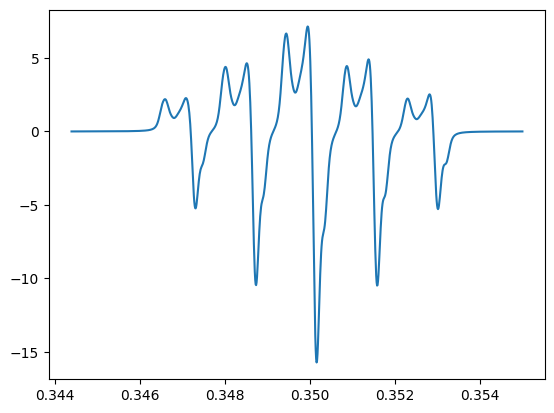

In [314]:
plt.plot(fields, out)

In [315]:
mars.save("easyspin/out_4.mat", sample=sample_2_el_2_nuc, spectra_creator=creator, field=fields, format_type="easyspin")
data_frame = pd.DataFrame({"field": fields, "spec": out})

data_frame.to_csv(f"easyspin/spectrum_4.csv", header=False, index=False)

In [22]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4)

time_spectrum_calculation_full_pipeline(
    sample_creation_func=create_2_electrons_2_nuclei_sample,
    sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
    freq=freq, field_range=field_range, n_points=n_points, temperature=temperature,
    computational_details=computational_details,
    n_warmup=2, n_iterations=5,
)

(704.3579999823123,
 1.8159772926436686,
 [701.6925000352785,
  706.0592999914661,
  702.7036999352276,
  706.0700999572873,
  705.2643999923021])

#### Plot spectra together

In [408]:
def read_csv(name: str):
    # Read the CSV file - data is in rows, not columns
    df = pd.read_csv(f".\\easyspin\\{name}.csv", header=None)
    
    # First row is 'fields', second row is 'spectrum'
    # Skip the first column (labels) and get the data
    fields = df.iloc[0, 1:].values.astype(float)
    spectrum = df.iloc[1, 1:].values.astype(float)
    
    # Convert to torch tensors
    fields_tensor = torch.tensor(fields, dtype=dtype, device=device)
    spectrum_tensor = torch.tensor(spectrum, dtype=dtype, device=device)
    
    return fields_tensor, spectrum_tensor

#### Sample 1

In [385]:
spectrum_easyspin

tensor([ 1.3250e+00, -8.8012e-04], dtype=torch.float64)

In [409]:
name = "spec_easy_spin_1"
freq = 35.0 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_5_electrons = create_5_electrons_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_Mn,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_Mn, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


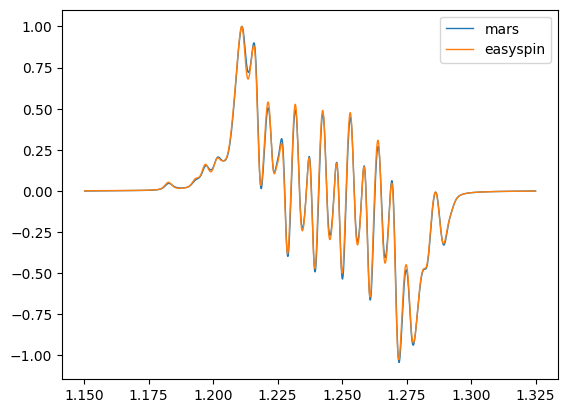

In [414]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_1.eps")
plt.show()

#### Sample 2

In [427]:
name = "spec_easy_spin_2"
freq = 35.0 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_two_spins = create_2_middle_spin_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_two_spins,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_two_spins, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


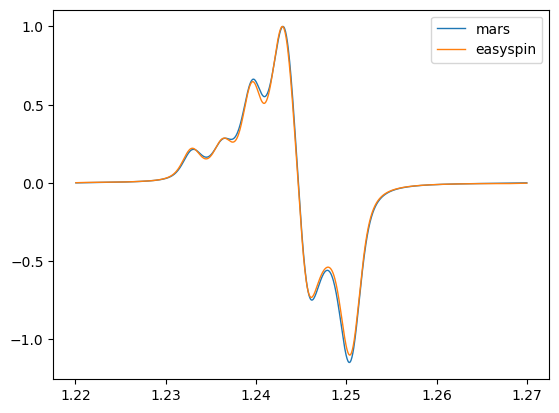

In [428]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_2.eps")
plt.show()

#### Sample 3

In [421]:
name = "spec_easy_spin_3"
freq = 9.8 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_5_electrons = create_5_electrons_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_5_electrons,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5_electrons, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


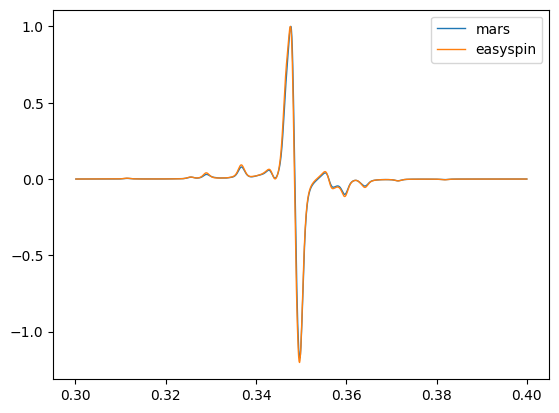

In [422]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_3.eps")
plt.show()

#### Sample 4

In [425]:
name = "spec_easy_spin_4"
freq = 9.8 * 1e9,
fields, spectrum_easyspin = read_csv(name)

sample_2_el_2_nuc = create_2_electrons_2_nuclei_sample(mesh=mesh, device="cpu", dtype=dtype)
creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2_el_2_nuc,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2_el_2_nuc, fields=fields)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


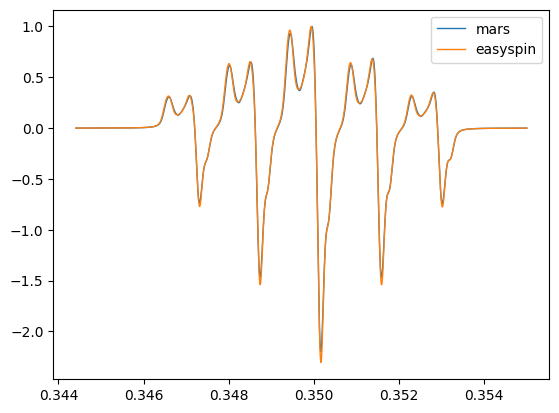

In [426]:
plt.plot(fields, out/ max(out), label="mars", linewidth=1)
plt.plot(fields, spectrum_easyspin / max(spectrum_easyspin), label="easyspin", linewidth=1)
plt.legend()
plt.savefig("example_4.eps")
plt.show()